In [1]:
from transformers import WhisperProcessor, WhisperForConditionalGeneration, AutoProcessor
from datasets import load_dataset, Audio
from src.ModelWrapper import ModelWrapper
import torch
from pyaml_env import parse_config
from src.utils_contributions import compute_alti
import pandas as pd
import seaborn as sns
#from transformers import pipeline

processor = WhisperProcessor.from_pretrained("openai/whisper-small")
#processor = AutoProcessor.from_pretrained("openai/whisper-small")
model = WhisperForConditionalGeneration.from_pretrained("openai/whisper-small", attn_implementation="eager")
torch_dtype = torch.float16 if torch.cuda.is_available() else torch.float32

device = "cuda" if torch.cuda.is_available() else "cpu"

model.to(device)
'''
print(model.forward.__annotations__)
print(model.config.output_attentions)
print(model.config.output_hidden_states)
print(model.config.return_dict)
print(config['models'][model.config.model_type])
print(model.config.num_attention_heads)
print(model.config.hidden_size / model.config.num_attention_heads)
print(device)
print(model.model.decoder)
'''     
# outputs = model(output_attentions=True, output_hidden_states=True)
# print(type(outputs))

"\nprint(model.forward.__annotations__)\nprint(model.config.output_attentions)\nprint(model.config.output_hidden_states)\nprint(model.config.return_dict)\nprint(config['models'][model.config.model_type])\nprint(model.config.num_attention_heads)\nprint(model.config.hidden_size / model.config.num_attention_heads)\nprint(device)\nprint(model.model.decoder)\n"

In [2]:
model_wrapped = ModelWrapper(model)

WhisperForConditionalGeneration(
  (model): WhisperModel(
    (encoder): WhisperEncoder(
      (conv1): Conv1d(80, 768, kernel_size=(3,), stride=(1,), padding=(1,))
      (conv2): Conv1d(768, 768, kernel_size=(3,), stride=(2,), padding=(1,))
      (embed_positions): Embedding(1500, 768)
      (layers): ModuleList(
        (0-11): 12 x WhisperEncoderLayer(
          (self_attn): WhisperAttention(
            (k_proj): Linear(in_features=768, out_features=768, bias=False)
            (v_proj): Linear(in_features=768, out_features=768, bias=True)
            (q_proj): Linear(in_features=768, out_features=768, bias=True)
            (out_proj): Linear(in_features=768, out_features=768, bias=True)
          )
          (self_attn_layer_norm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (activation_fn): GELUActivation()
          (fc1): Linear(in_features=768, out_features=3072, bias=True)
          (fc2): Linear(in_features=3072, out_features=768, bias=True)
          (f

In [3]:
ds = load_dataset("CristianaLazar/librispeech_test")

In [4]:
def contains_word(example, word):
    return word in example["text"].lower().split()

def transcribe(dataset):
    transcribed_data = []
    generated_ids = []
    decoded_texts = []
    for i, sample in enumerate(dataset):
        audio = sample["audio"]
        inputs = processor(
            audio["array"],
            sampling_rate=audio["sampling_rate"],
            return_tensors="pt",
            return_attention_mask=True
        )
        input_features = inputs.input_features.to(model.device)
        attention_mask = inputs.attention_mask.to(model.device)
        
        generated_ids.append(model.generate(input_features,attention_mask=attention_mask, language="en", task="transcribe", return_token_timestamps=True))
        decoded_texts.append(processor.batch_decode(generated_ids[i]['sequences'], skip_special_tokens=True, decode_with_timestamps=False)[0])
        transcribed_data.append(decoded_texts[i])
    return transcribed_data, generated_ids, decoded_texts

def get_input_features(dataset):
    audio = sample["audio"]
    inputs = (processor(
        audio["array"],
        sampling_rate=audio["sampling_rate"],
        return_tensors="pt",
        return_attention_mask=True
    ))
    input_features = inputs.input_features.to(model.device)
    attention_mask = inputs.attention_mask.to(model.device)
    return input_features, attention_mask

def add_forced_ids(gen_ids):
    # get prompt tokens and append to token list
    forced_ids = model.generation_config.forced_decoder_ids
    task_token_id = forced_ids[1][1]
    full_ids = gen_ids['sequences'][0].tolist()
    full_ids.insert(0, task_token_id)
    return torch.tensor(full_ids)

def build_decoder_prefix(decoded_ids_tensor, target_token, skip_special_tokens=True):
    seq = decoded_ids_tensor.tolist()
    assert target_token in seq, "Target token not found in decoded output"
    target_pos = seq.index(target_token)
    
    # decoder prefix
    decoder_input_ids = torch.tensor(
        seq[:target_pos],
        device=model.device
    ).unsqueeze(0)
    return decoder_input_ids

In [5]:
pair_homophones = ds.filter(
    lambda ex: contains_word(ex, "pair") or contains_word(ex, "pear")
)
print(len(pair_homophones))

1


In [6]:
print(pair_homophones["test"])
transcriptions, _, _ = transcribe(pair_homophones['test'])

for i, t in enumerate(transcriptions):
    print(f"Sample {i}: {t}")

Dataset({
    features: ['file', 'audio', 'text', 'speaker_id', 'chapter_id', 'id', 'input_features', 'labels'],
    num_rows: 5
})
Sample 0:  This thought, however, did not enter the heads of the enthusiastic pair.
Sample 1:  It was the white rabbit returning, splendidly dressed with a pair of white kid gloves in one hand and a large fan in the other. He came trotting along in a great hurry, muttering to himself as he came. Oh, the Duchess, the Duchess!
Sample 2:  For it is a solid, heavy, handsome door, and must once have been in the habit of shutting with a sonorous bang behind the liveried lackey, who had just seen his master and mistress off the grounds in a carriage and pair.
Sample 3:  Pester Prynne went one day to the mansion of Governor Bellingham with a pair of gloves which she had fringed and embroidered to his order, and which were to be worn on some great occasion of state. For, though the chances of a popular election had caused this former ruler to descend a step or two 

In [7]:
# define contrastive tokens
target = " pair"
foil = " pear"

CORRECT_ID = processor.tokenizer(target, add_special_tokens=False).input_ids[0]
FOIL_ID = processor.tokenizer(foil, add_special_tokens=False).input_ids[0]
token = [CORRECT_ID, FOIL_ID]

results = []

for i, sample in enumerate(pair_homophones["test"]):
    print(f"\nProcessing sample {i}")

    # get audio features for ONE sample
    input_features, attention_mask = get_input_features(sample)

    # generate transcription
    generated_ids = model.generate(
        input_features,
        attention_mask=attention_mask,
        language="en",
        task="transcribe",
        return_token_timestamps=True
    )

    # generated token ids (batch size = 1)
    full_ids_tensor = generated_ids["sequences"][0]

    # build forced decoder prefix
    decoder_input_ids = build_decoder_prefix(
        full_ids_tensor,
        CORRECT_ID,
        False
    )

    # forward pass with forced decoder prefix
    (
        prediction_scores,
        hidden_states,
        attentions,
        encoder_hidden_states,
        cross_attentions
    ) = model_wrapped({
        "input_features": input_features,
        "decoder_input_ids": decoder_input_ids
    })

    # logit difference at decision point
    step_logits = prediction_scores[0, -1]
    logit_diff = step_logits[CORRECT_ID] - step_logits[FOIL_ID]

    print("logit diff:", logit_diff.item())

    # logit attribution
    logit_trans_vect_dict, logits_modules, layer_alti_data = (
        model_wrapped.get_logit_contributions(
            hidden_states=hidden_states,
            attentions=attentions,
            token=token,
            output_pos=-1,
            encoder_hidden_states=encoder_hidden_states,
            cross_attentions=cross_attentions
        )
    )

    results.append({
        "logit_diff": logit_diff.detach().cpu(),
        "logit_trans_vect_dict": logit_trans_vect_dict,
        "layer_attributions": layer_alti_data,
        "decoder_input_ids": decoder_input_ids,
        "logits_modules": logits_modules
    })



Processing sample 0
logit diff: 5.499987602233887
model.decoder.layers
model.decoder.layers
model.decoder.layers
l_lin_enc_x_i_heads:  torch.Size([1, 13, 768])
unembed:  torch.Size([2, 768])
model.decoder.layers
l_lin_enc_x_i_heads:  torch.Size([1, 13, 768])
unembed:  torch.Size([2, 768])
model.decoder.layers
l_lin_enc_x_i_heads:  torch.Size([1, 13, 768])
unembed:  torch.Size([2, 768])
model.decoder.layers
l_lin_enc_x_i_heads:  torch.Size([1, 13, 768])
unembed:  torch.Size([2, 768])
model.decoder.layers
l_lin_enc_x_i_heads:  torch.Size([1, 13, 768])
unembed:  torch.Size([2, 768])
model.decoder.layers
l_lin_enc_x_i_heads:  torch.Size([1, 13, 768])
unembed:  torch.Size([2, 768])
model.decoder.layers
l_lin_enc_x_i_heads:  torch.Size([1, 13, 768])
unembed:  torch.Size([2, 768])
model.decoder.layers
l_lin_enc_x_i_heads:  torch.Size([1, 13, 768])
unembed:  torch.Size([2, 768])
model.decoder.layers
l_lin_enc_x_i_heads:  torch.Size([1, 13, 768])
unembed:  torch.Size([2, 768])
model.decoder.la

In [8]:

'''contrastive_contributions = (
    layer_alti_data[CORRECT_ID] - layer_alti_data[FOIL_ID]
)

print(contrastive_contributions)'''

'contrastive_contributions = (\n    layer_alti_data[CORRECT_ID] - layer_alti_data[FOIL_ID]\n)\n\nprint(contrastive_contributions)'

## Token to token ALTI heatmap
- interaction strength between decoder tokens
- measures how earlier tokens influence later token logits
- Strong diagonal -> self-dependence
- off diagonal -> long-range linguistic dependence

In [17]:
import numpy as np
import matplotlib.pyplot as plt
def plot_token_alti(layer_alti_data, decoder_input_ids, sample_idx):
    contributions_mix_alti = compute_alti(layer_alti_data)

    tokens = processor.tokenizer.convert_ids_to_tokens(
        decoder_input_ids[0].tolist()
    )

    df = pd.DataFrame(
        np.array(contributions_mix_alti[-1]),
        columns=tokens,
        index=tokens
    )

    sns.heatmap(df, cmap="Blues", square=True)
    plt.title(f"Token-to-token ALTI (sample {sample_idx})")
    plt.show()

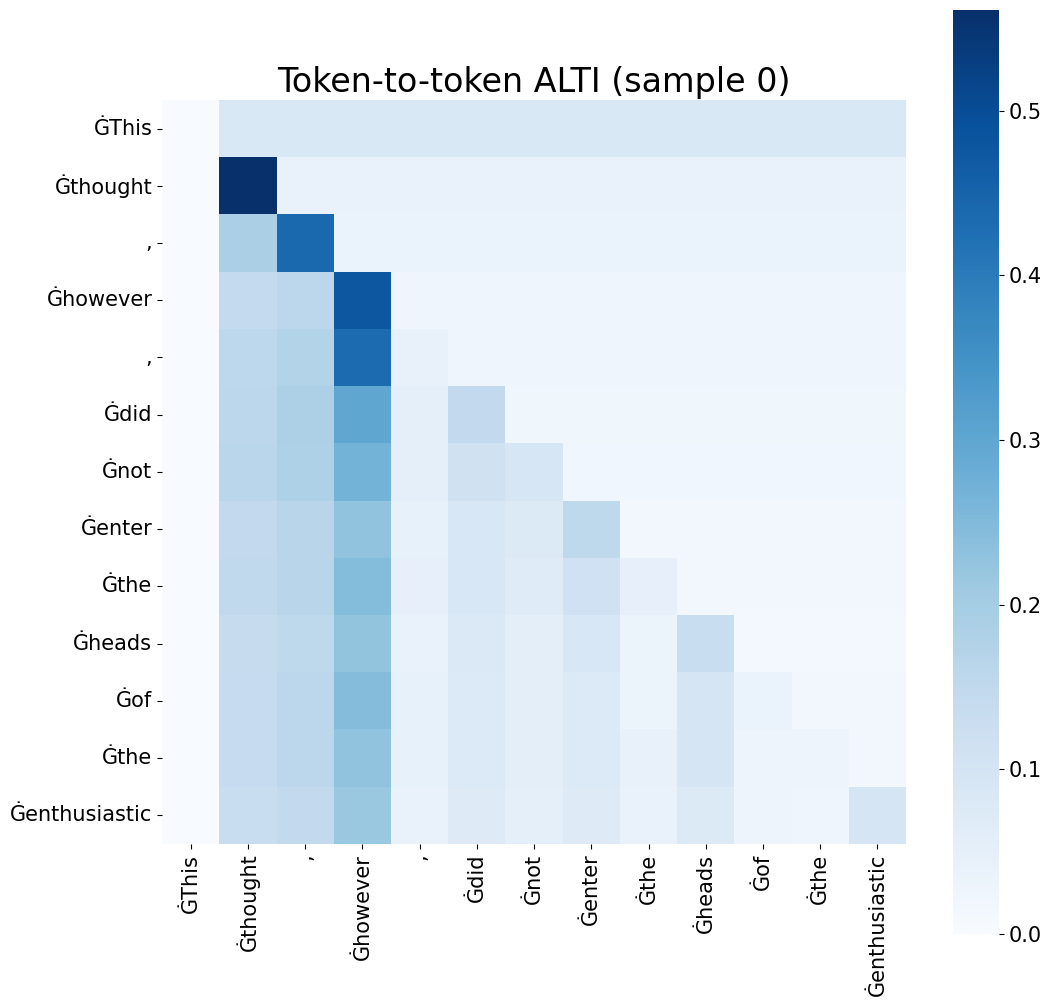

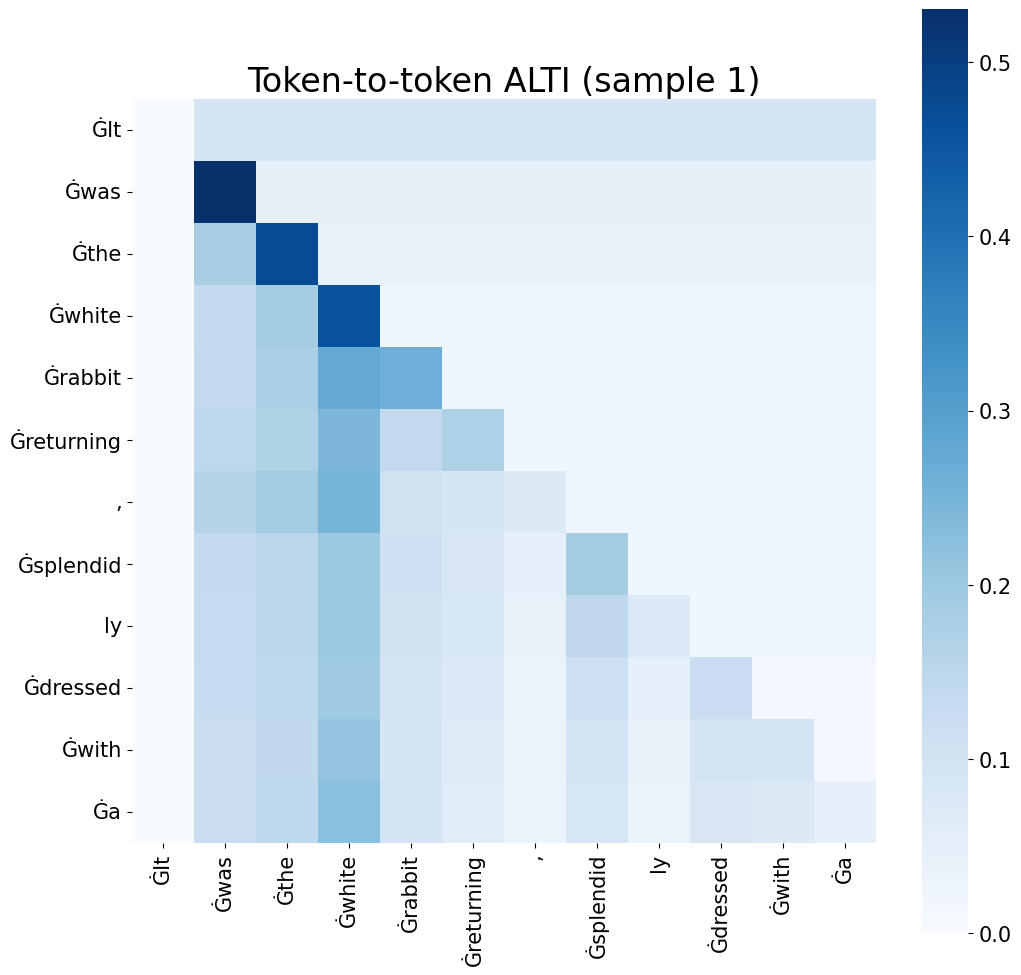

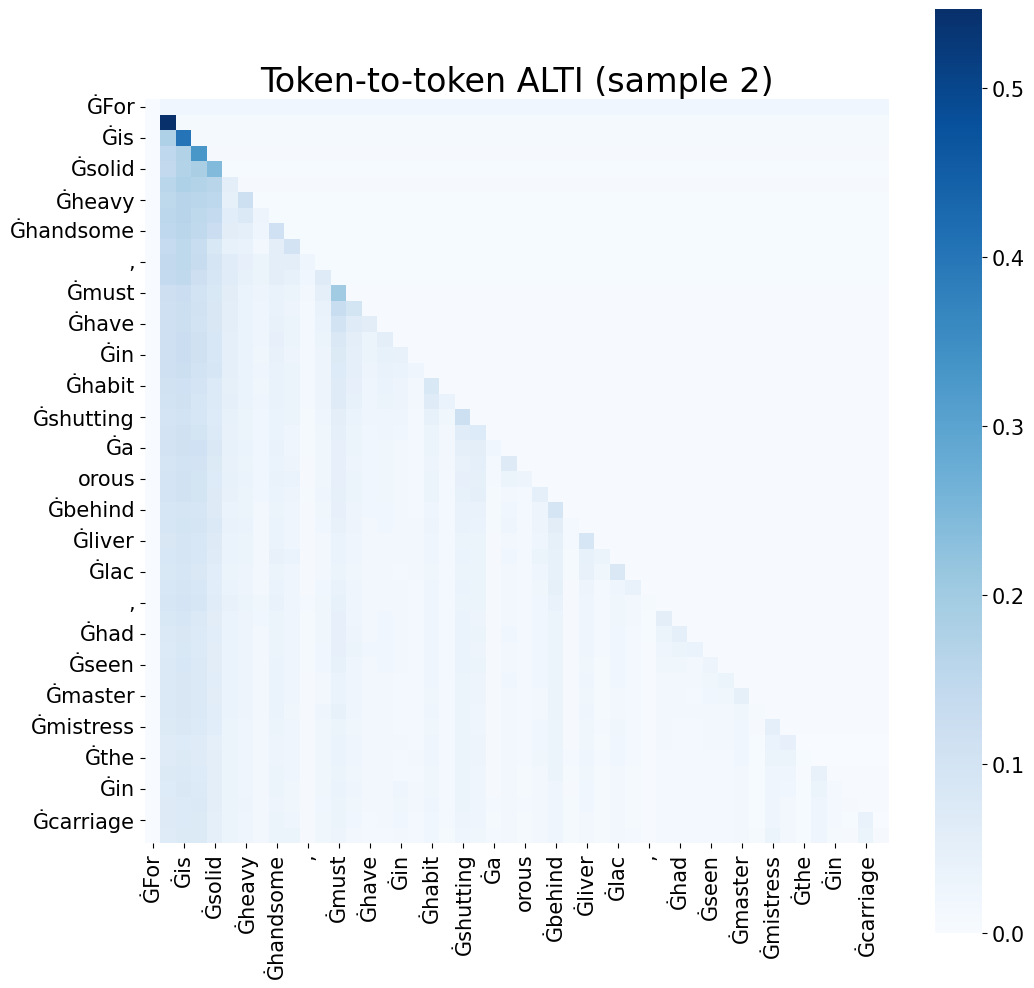

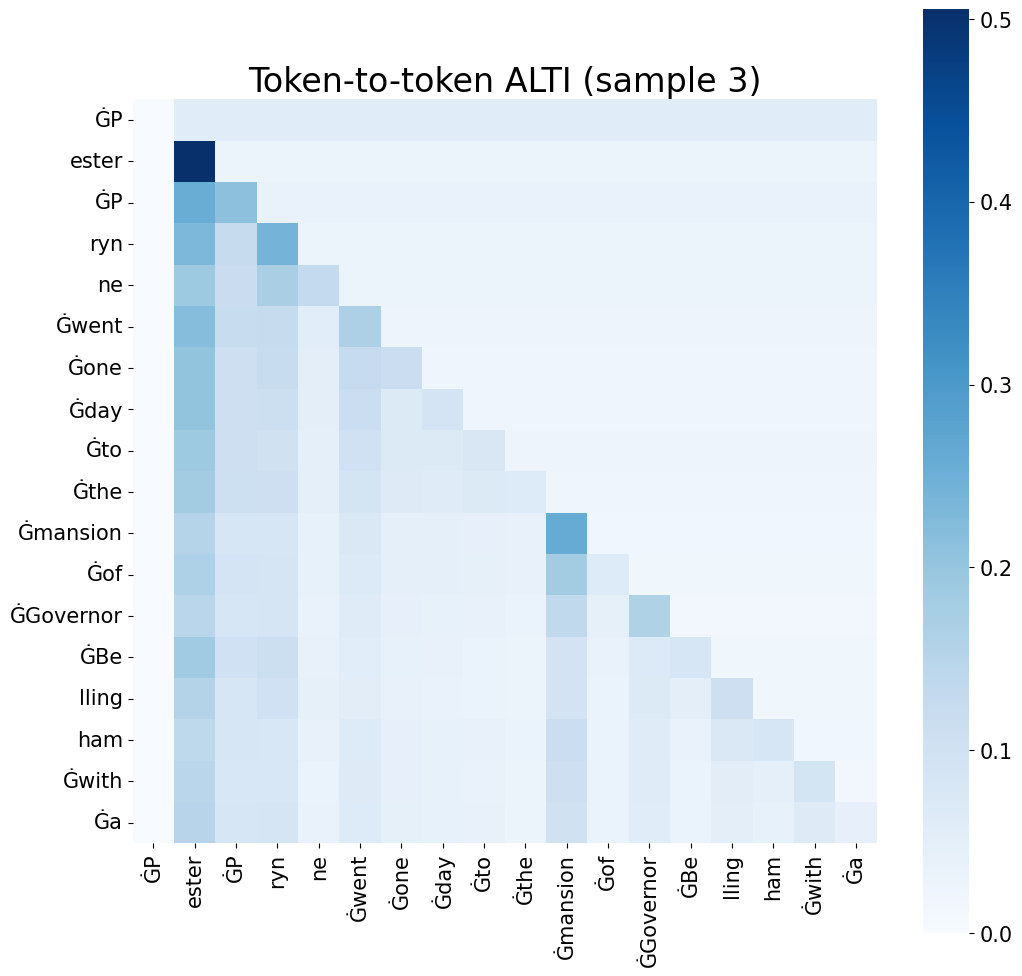

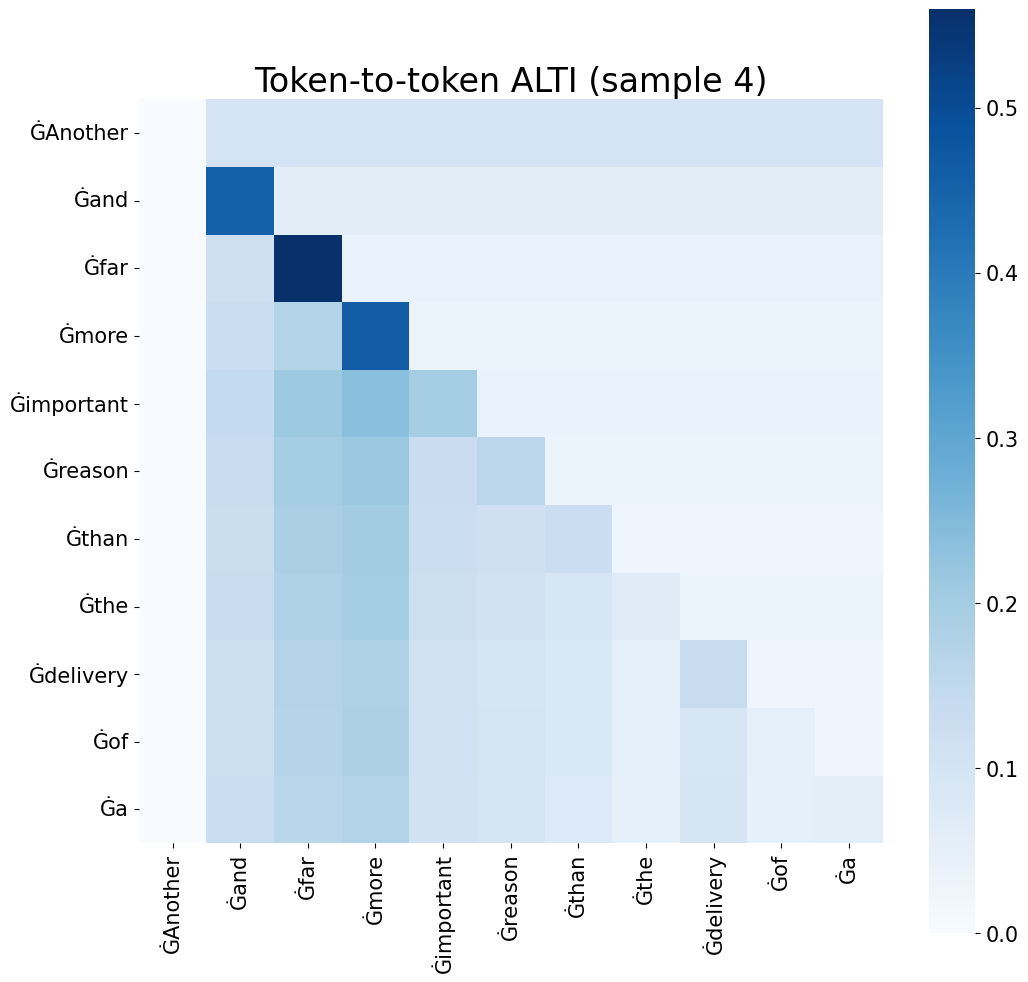

In [18]:
for i, result in enumerate(results):
    plot_token_alti(result["layer_attributions"],result["decoder_input_ids"],i)

## Layer × token heatmap
- shows how different decoder layers attend to different audio frames
- aggregated contribution per layer
- lower layers: local acoustic features
- higher layers: phoneme-level or semantic aggregation

In [31]:
def plot_layer_token_heatmap(logit_trans_vect_dict, sample_idx):
    frame_contributions = (
        logit_trans_vect_dict["lin_x_j_h"]
        .sum(axis=1)
        .sum(axis=-1)
    )  # [layers, tgt_len, src_len]

    fc_all = frame_contributions.cpu().numpy()
    fc_all = fc_all[..., 0] - fc_all[..., 1]
    #fc_all = (fc_all - fc_all.min(axis=1, keepdims=True)) / (
    #    fc_all.max(axis=1, keepdims=True) - fc_all.min(axis=1, keepdims=True) + 1e-8
    #)

    df = pd.DataFrame(
        fc_all,
        columns=[f"token_{i}" for i in range(fc_all.shape[1])],
        index=[f"layer_{i}" for i in range(fc_all.shape[0])]
    )

    sns.heatmap(df, cmap="Blues", cbar=True)
    plt.title(f"Layer × Frame contributions (sample {sample_idx})")
    plt.show()

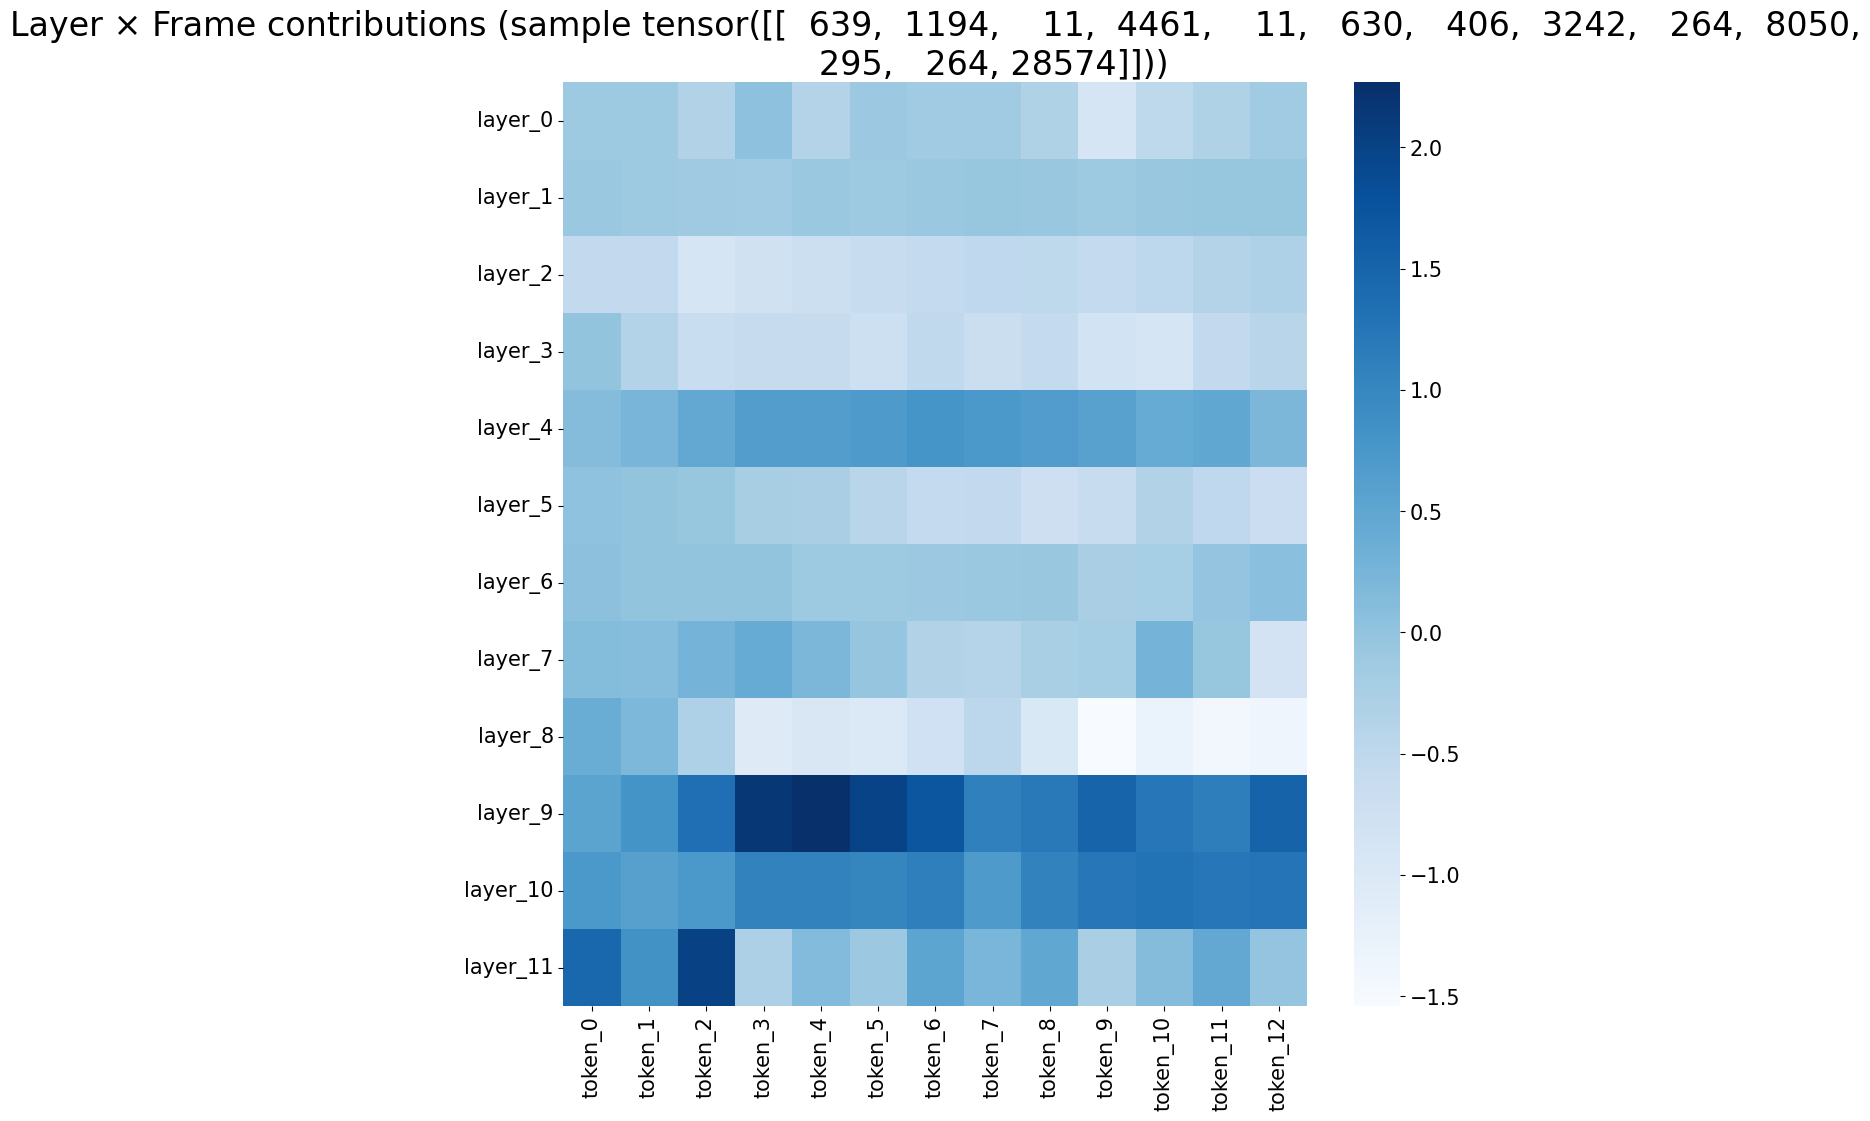

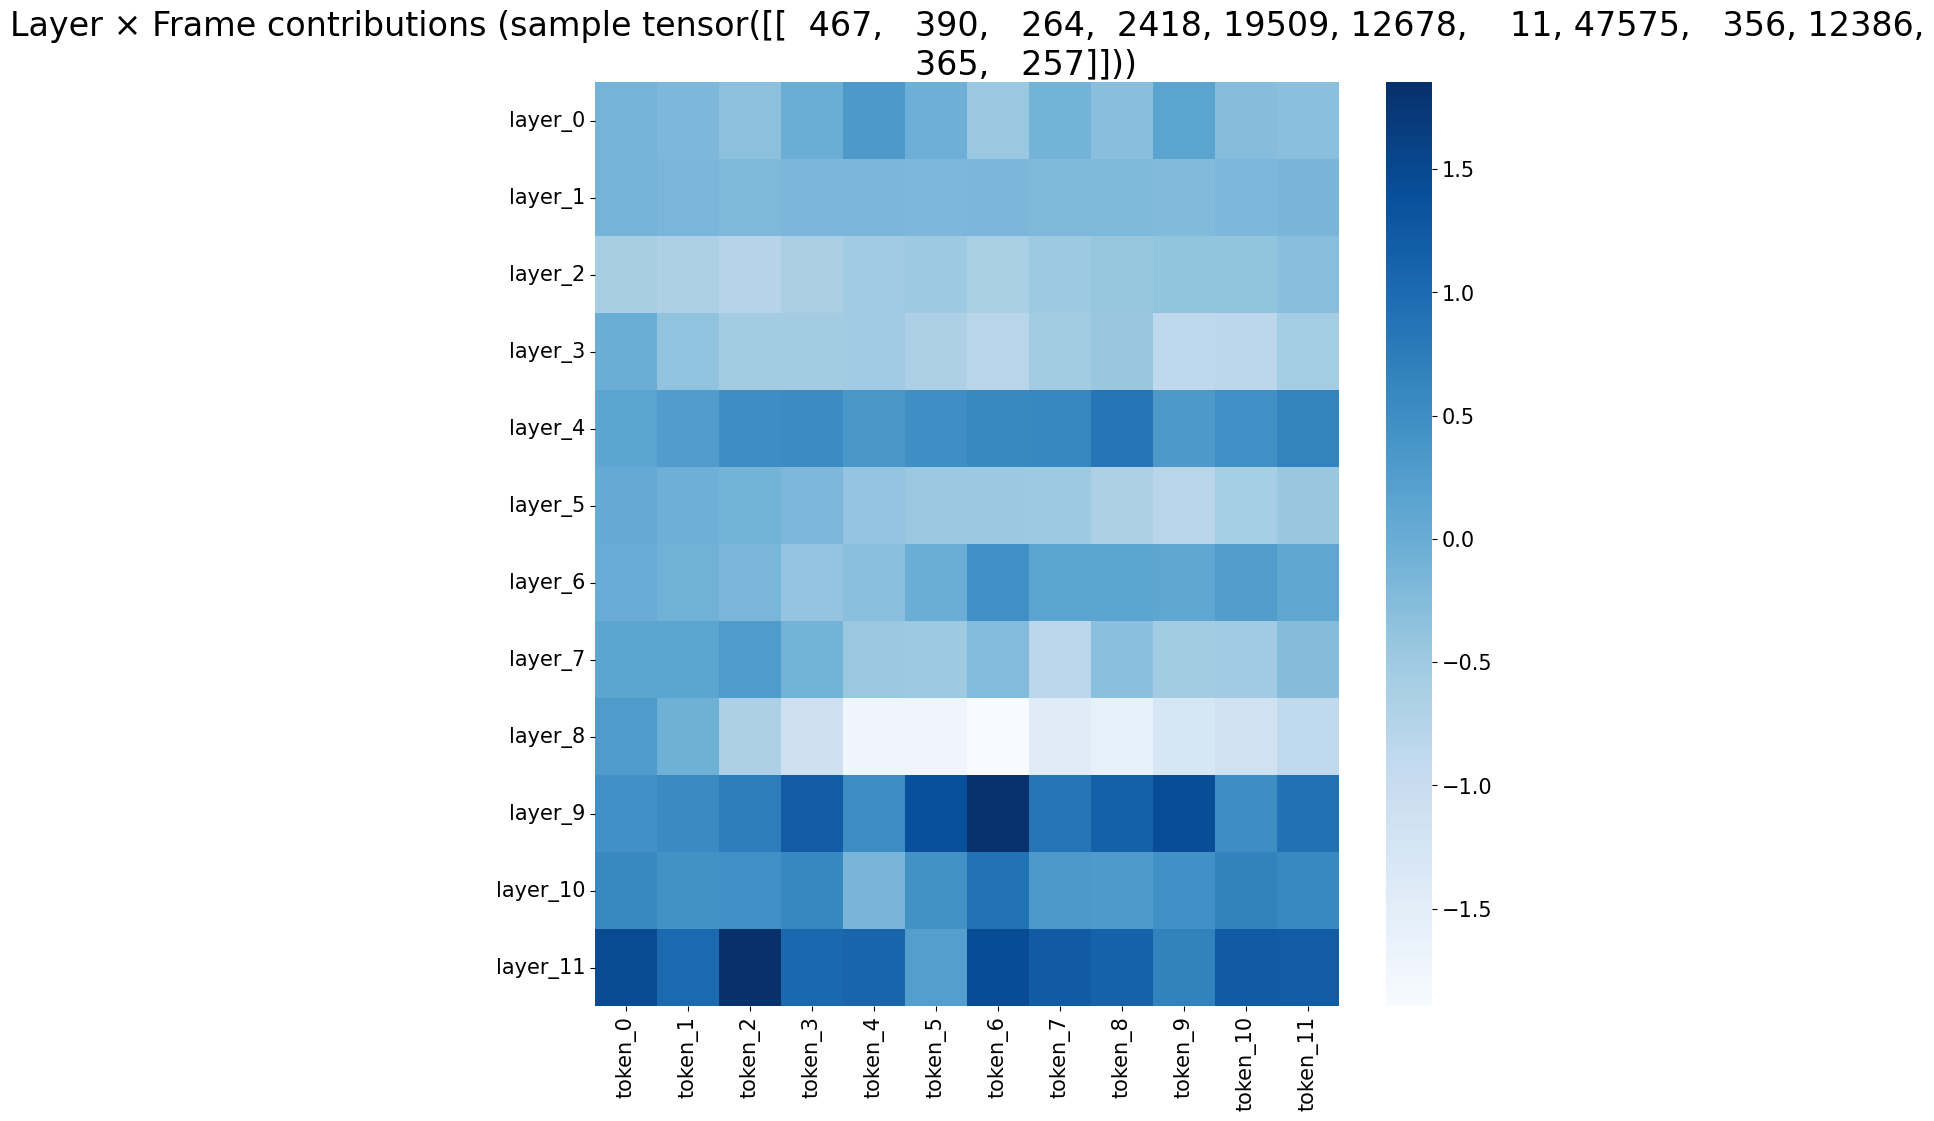

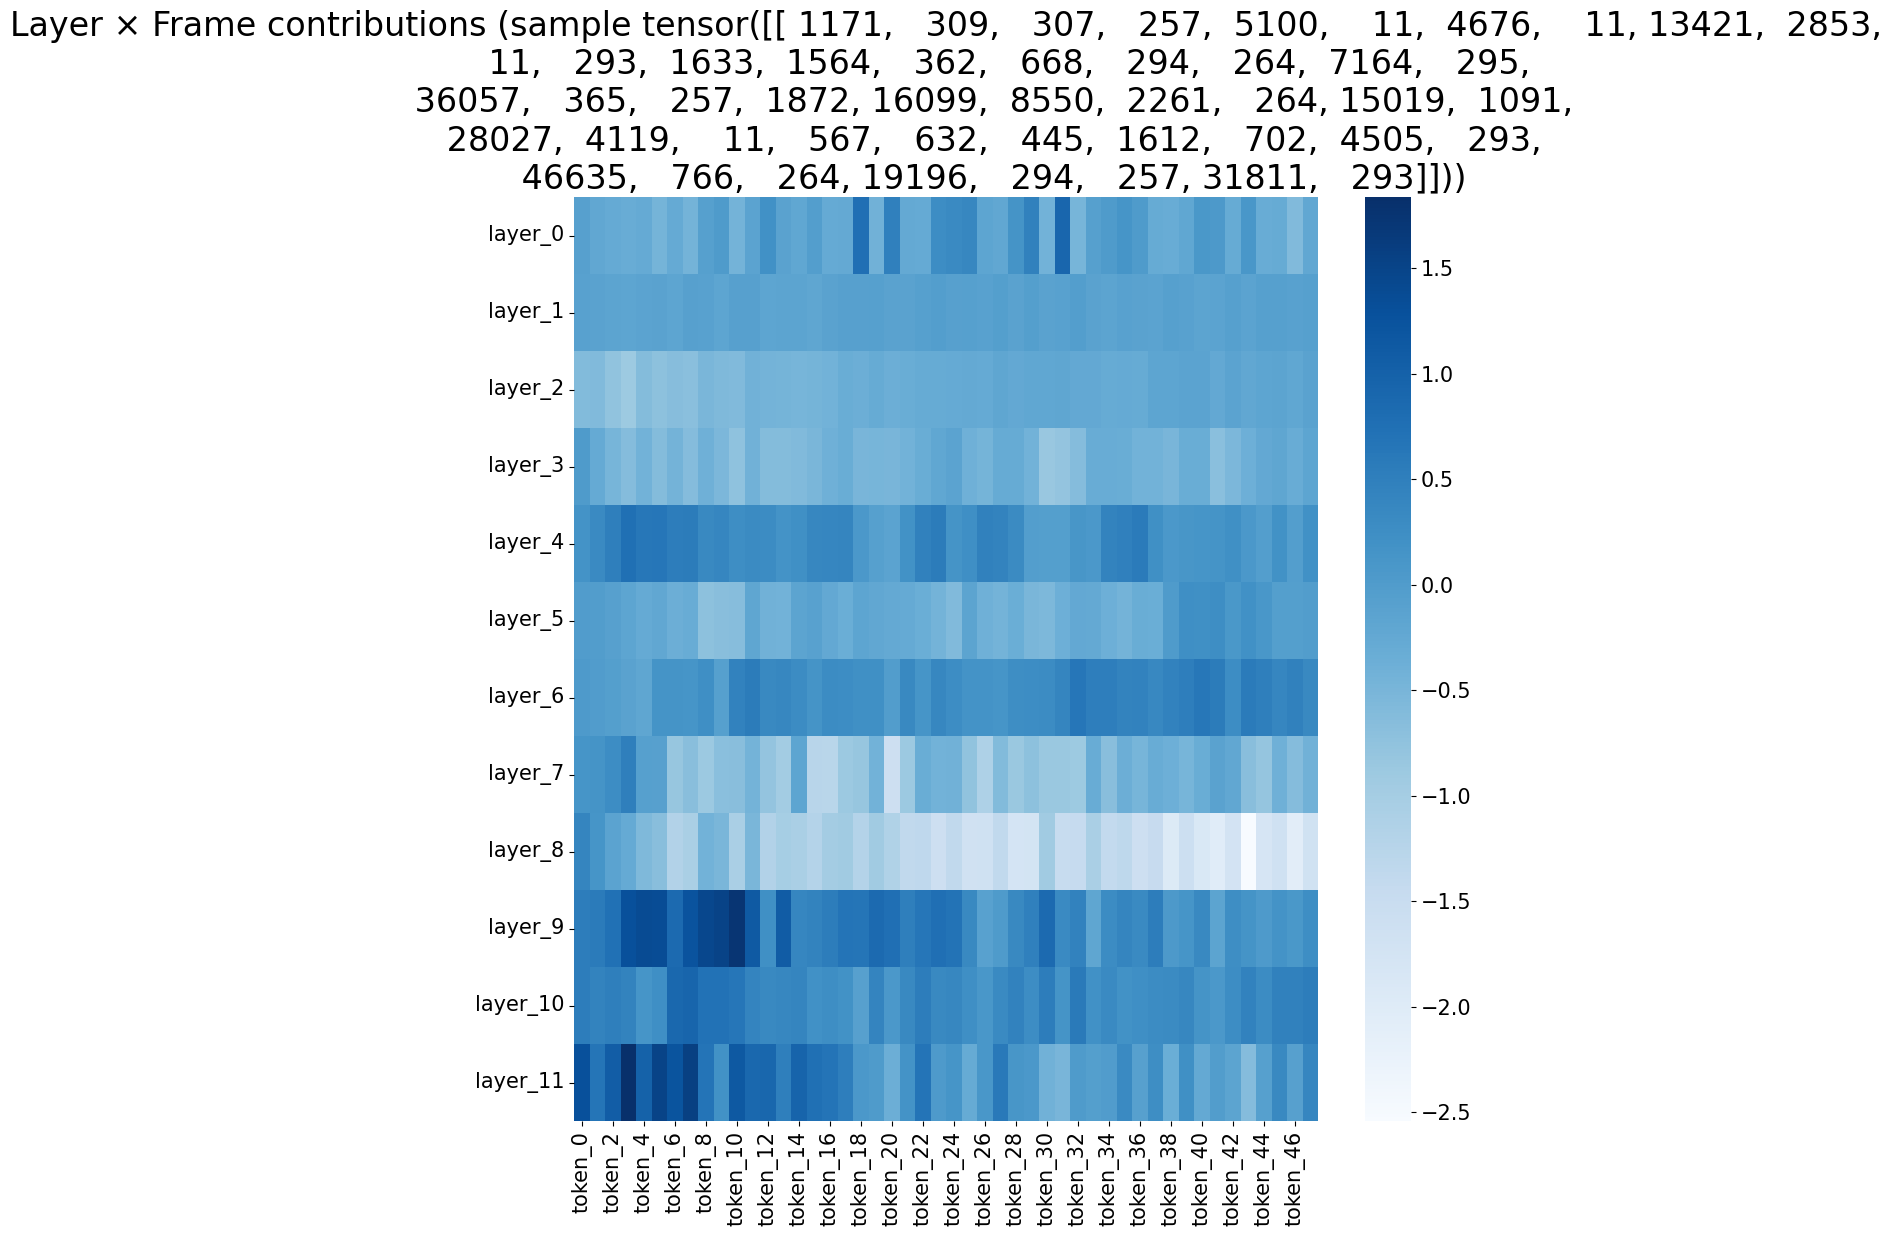

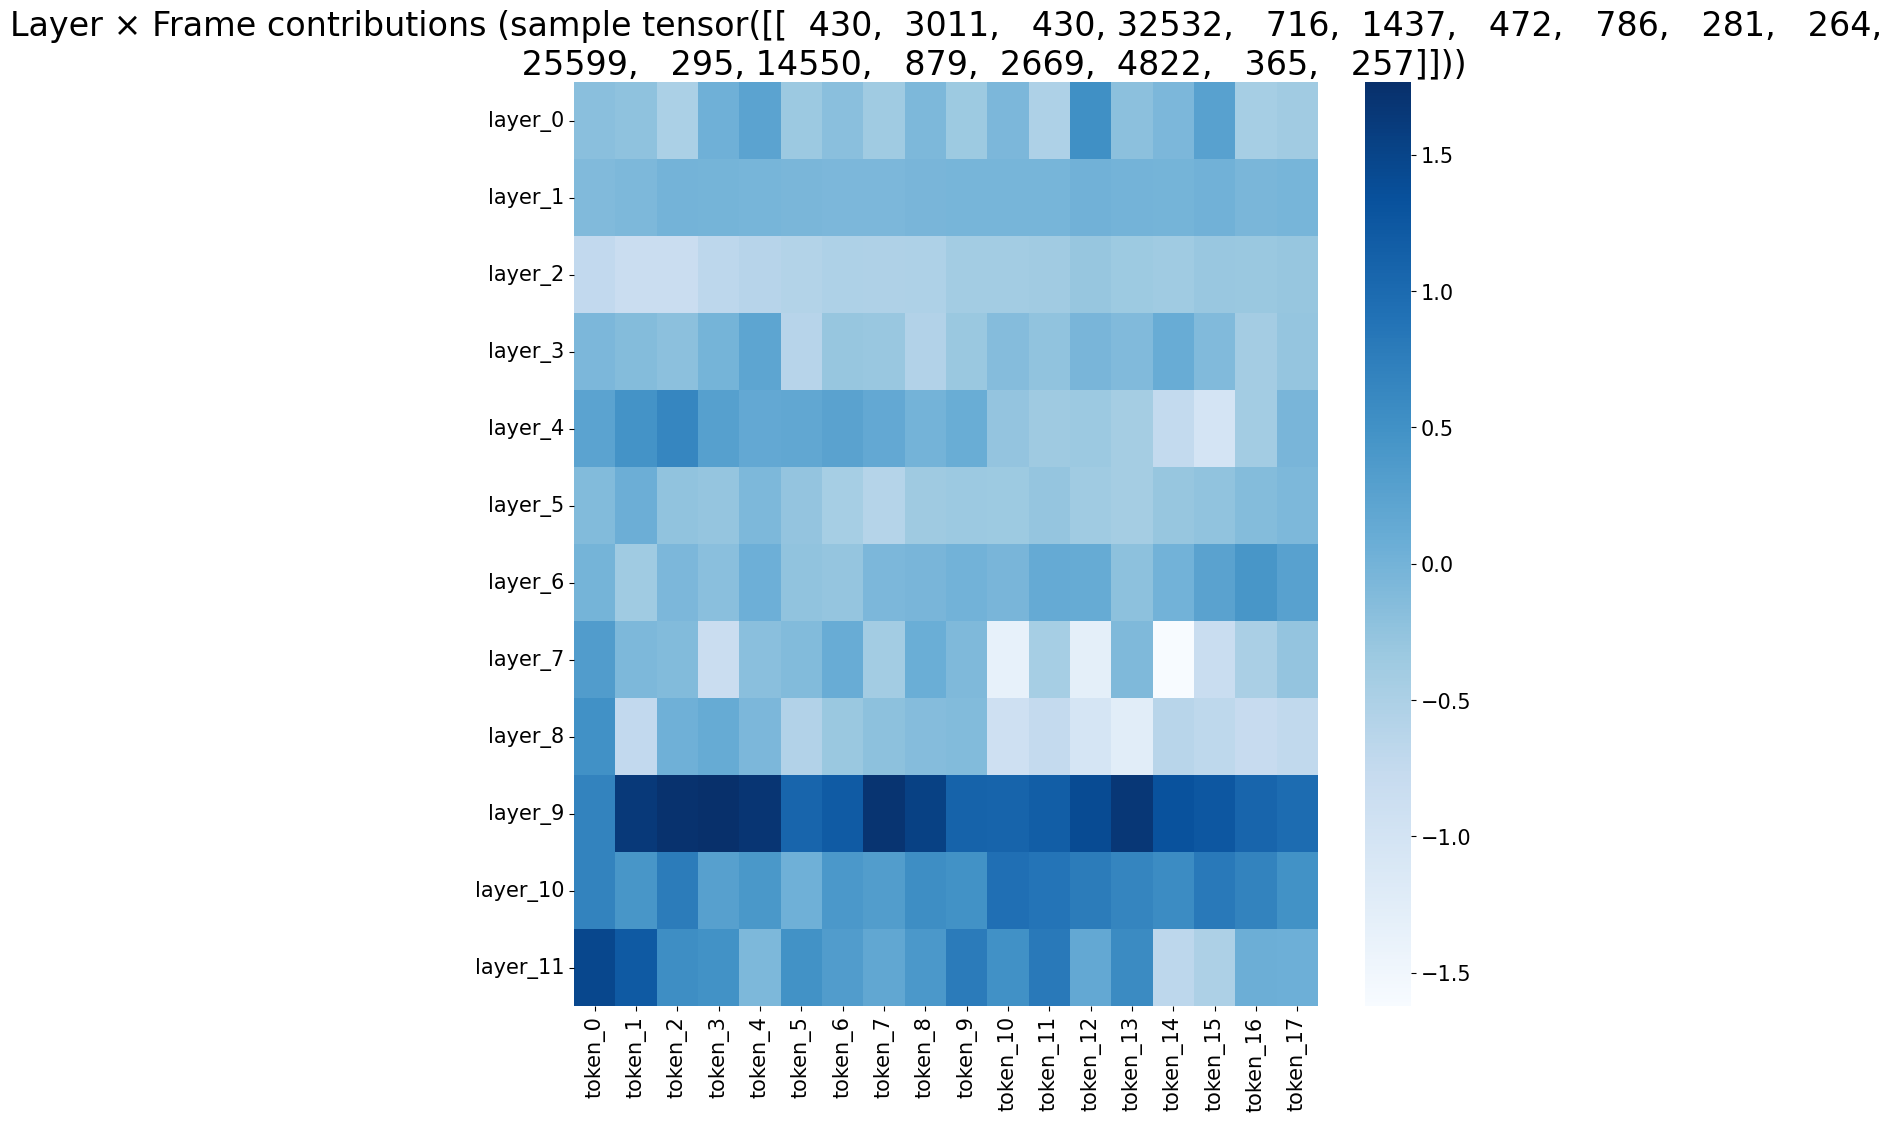

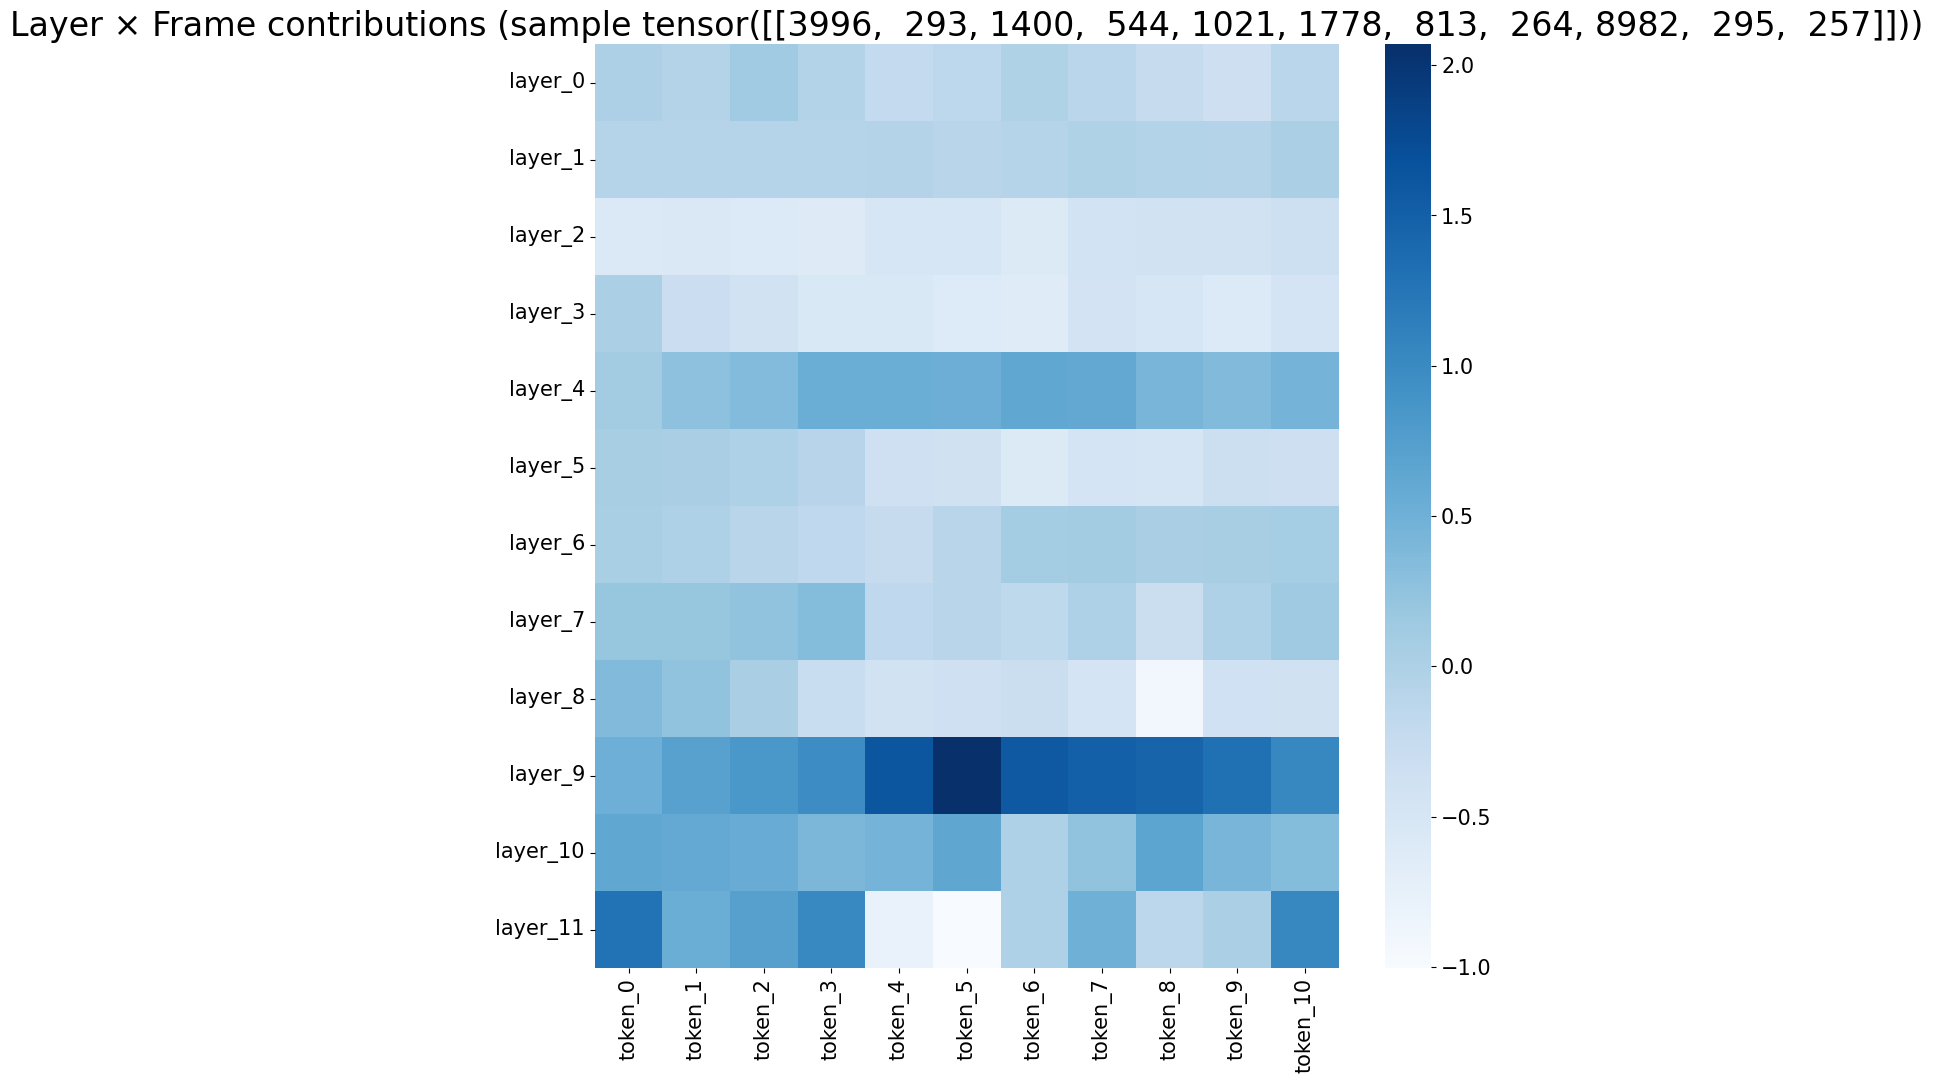

In [32]:
for i, result in enumerate(results):
    plot_layer_token_heatmap(result["logit_trans_vect_dict"],result["decoder_input_ids"])

## Frame contribution curve
- one-dimensional summary of frame importance
- peaks = decisive acoustic evidence
- compare curves across samples to see consistency of evidence

In [26]:
def plot_frame_curve(logit_trans_vect_dict, layer_idx=-1, sample_idx=0):
    frame_contributions = (
        logit_trans_vect_dict["lin_x_j_h"]
        .sum(axis=1)
        .sum(axis=-1)
    )

    fc = frame_contributions[layer_idx]
    fc = (fc - fc.min()) / (fc.max() - fc.min() + 1e-8)

    plt.plot(fc.cpu().numpy())
    plt.xlabel("Decoder token")
    plt.ylabel("Contribution magnitude")
    plt.title(f"Token contribution curve (layer {layer_idx}, sample {sample_idx})")
    plt.show()


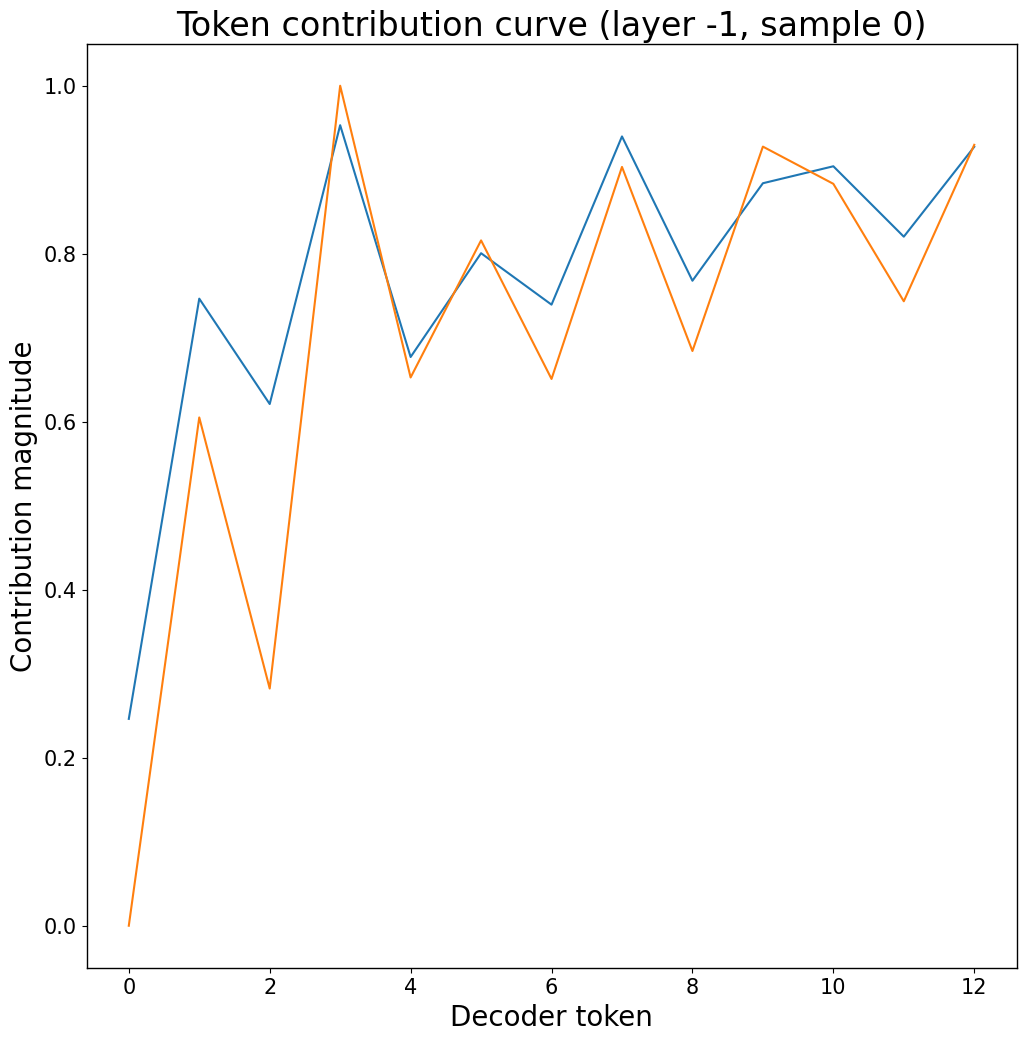

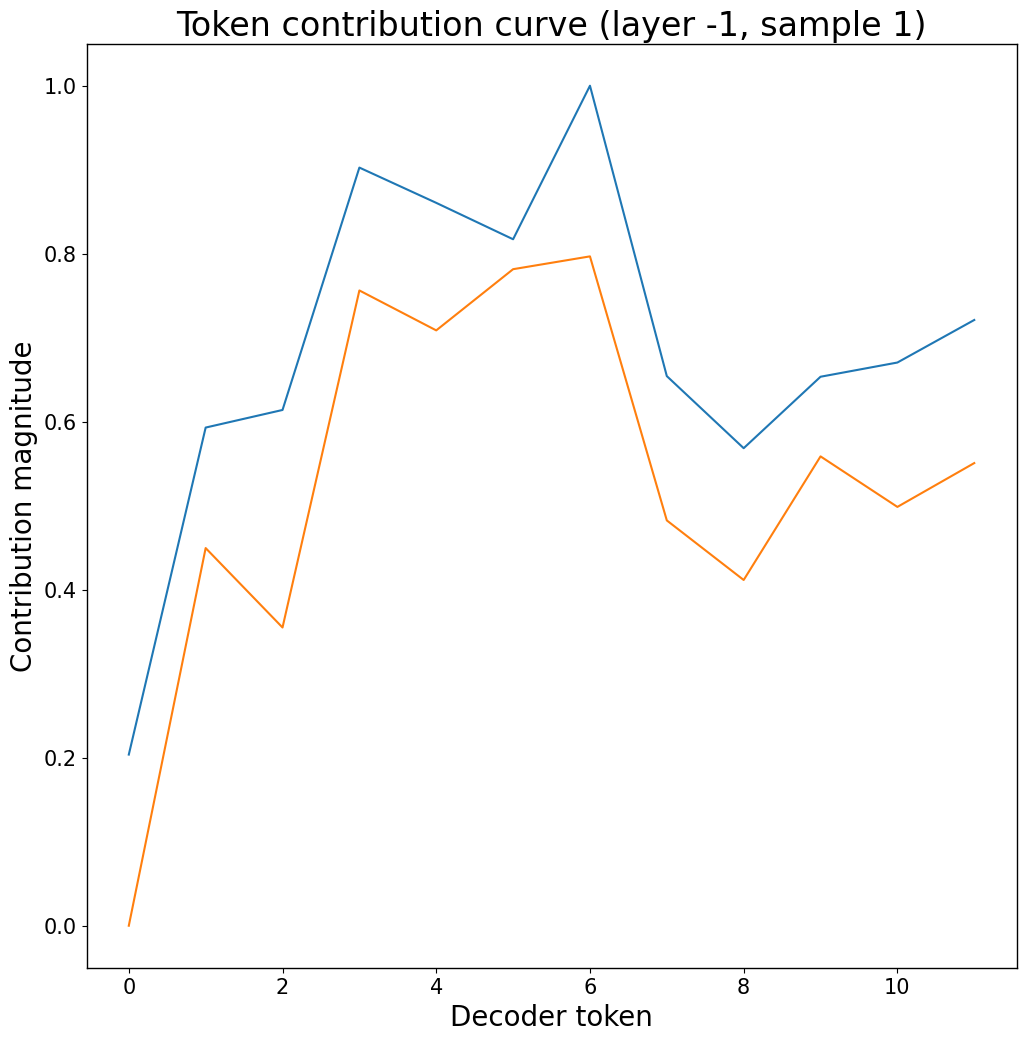

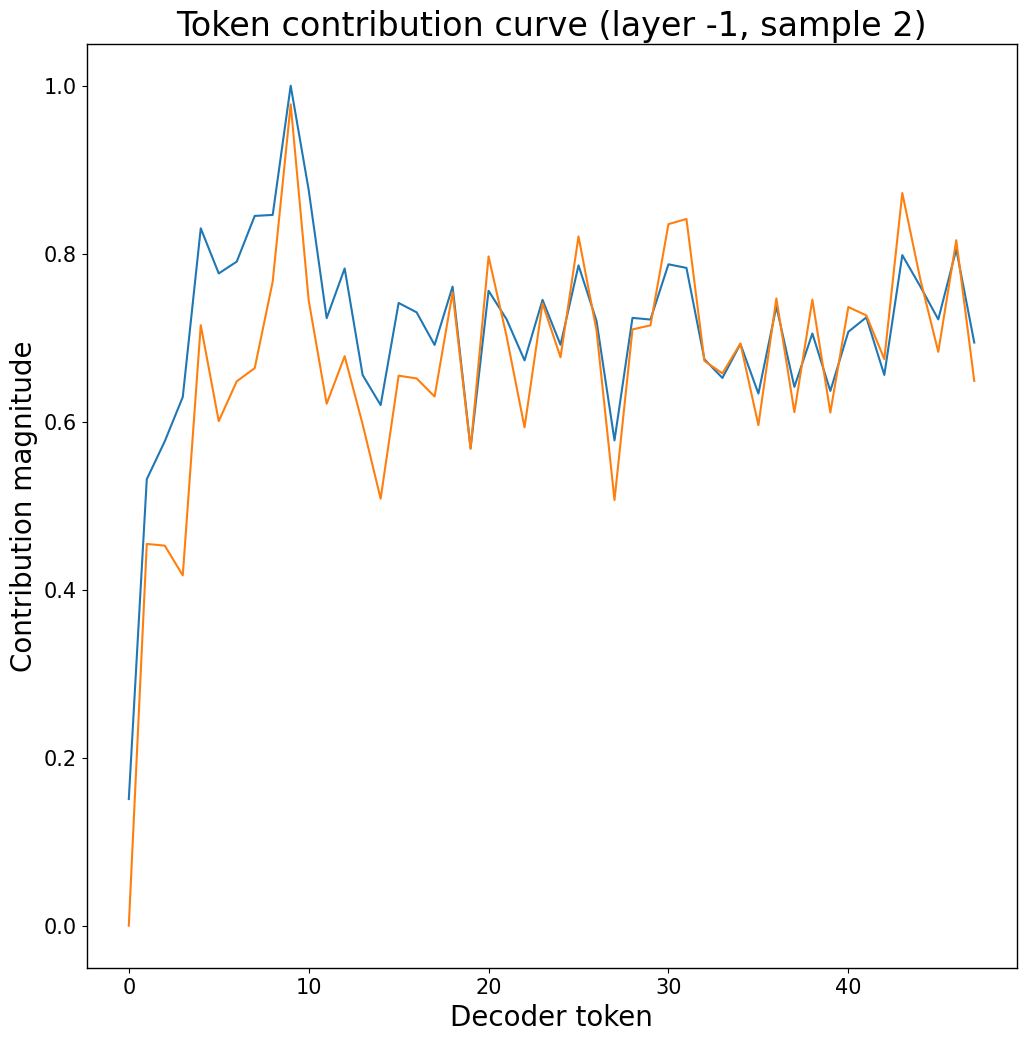

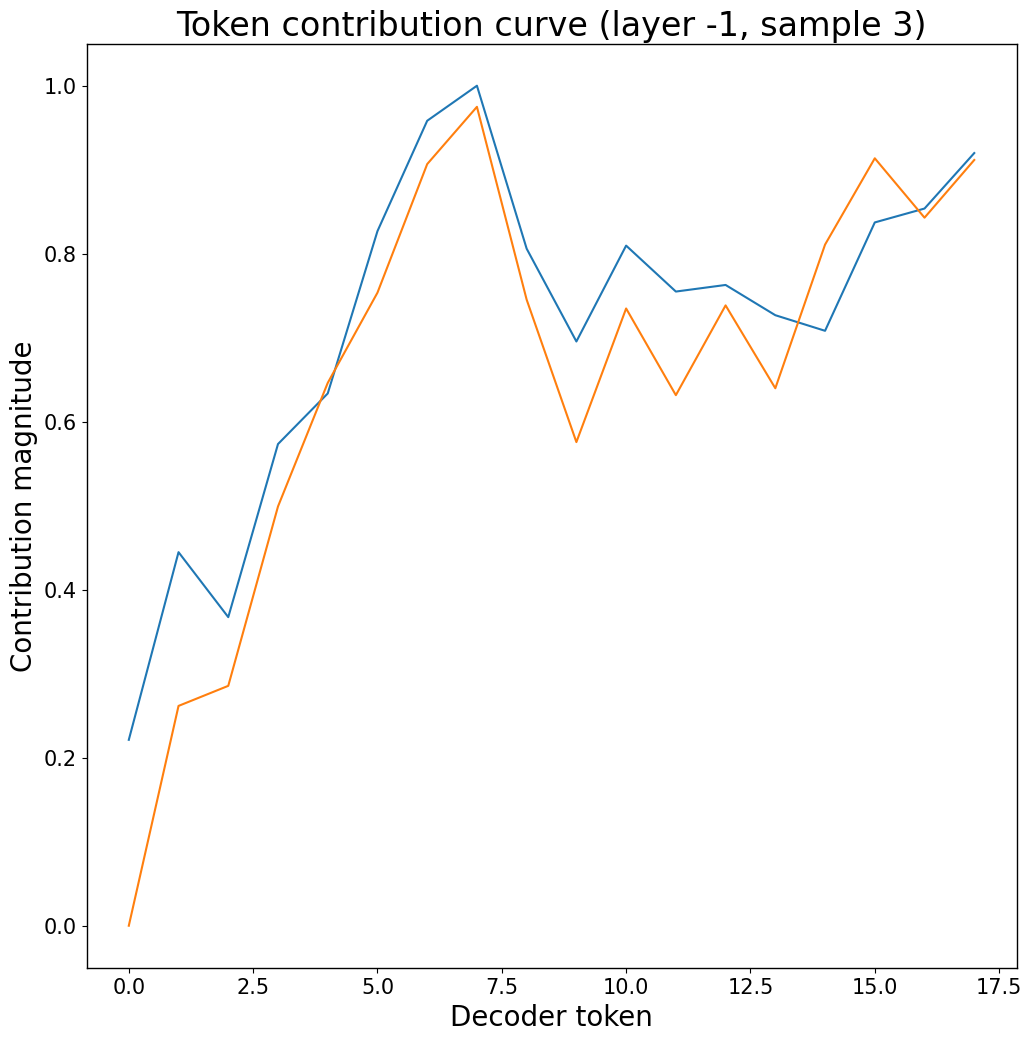

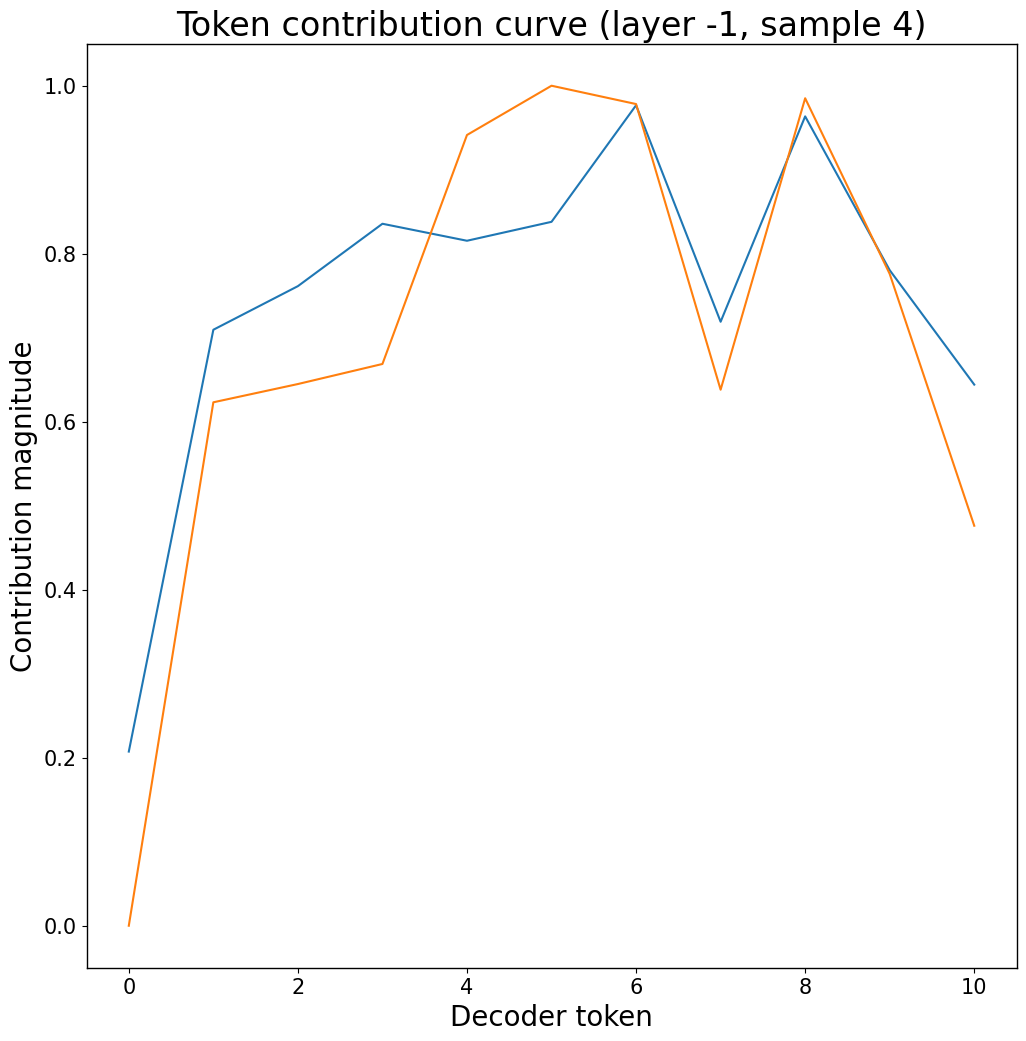

In [28]:
for i, result in enumerate(results):
    plot_frame_curve(result["logit_trans_vect_dict"],layer_idx=-1,sample_idx=i)

## Contrastive token saliency
- token-level contributions to the logit difference
- positive contribution → pushes model toward pair
- negative contribution → pushes toward pear
- reveals where the model commits to one homophone

In [37]:
from extract_explanations import track2input_tokens
from lm_saliency import *

def plot_contrastive_token_saliency(
    logit_trans_vect_dict,
    layer_alti_data,
    logits_modules,
    decoder_input_ids,
    token
):
    methods_decomp = ["aff_x_j"]
    contributions_mix_alti = compute_alti(layer_alti_data)

    alti_lg_dict = track2input_tokens(
        logit_trans_vect_dict,
        methods_decomp,
        contributions_mix_alti,
        token
    )

    contrastive = (
        alti_lg_dict["logit_aff_x_j"][0]
        - alti_lg_dict["logit_aff_x_j"][1]
    ).sum(0)

    # add initial logit contribution
    contrastive[-1] += (
        logits_modules["init_logit"][0]
        - logits_modules["init_logit"][1]
    ).cpu()

    # L1 normalization
    contrastive /= np.linalg.norm(contrastive, ord=1)

    visualize(
        np.array(contrastive),
        processor.tokenizer,
        decoder_input_ids,
        print_text=True,
        normalize=False
    )


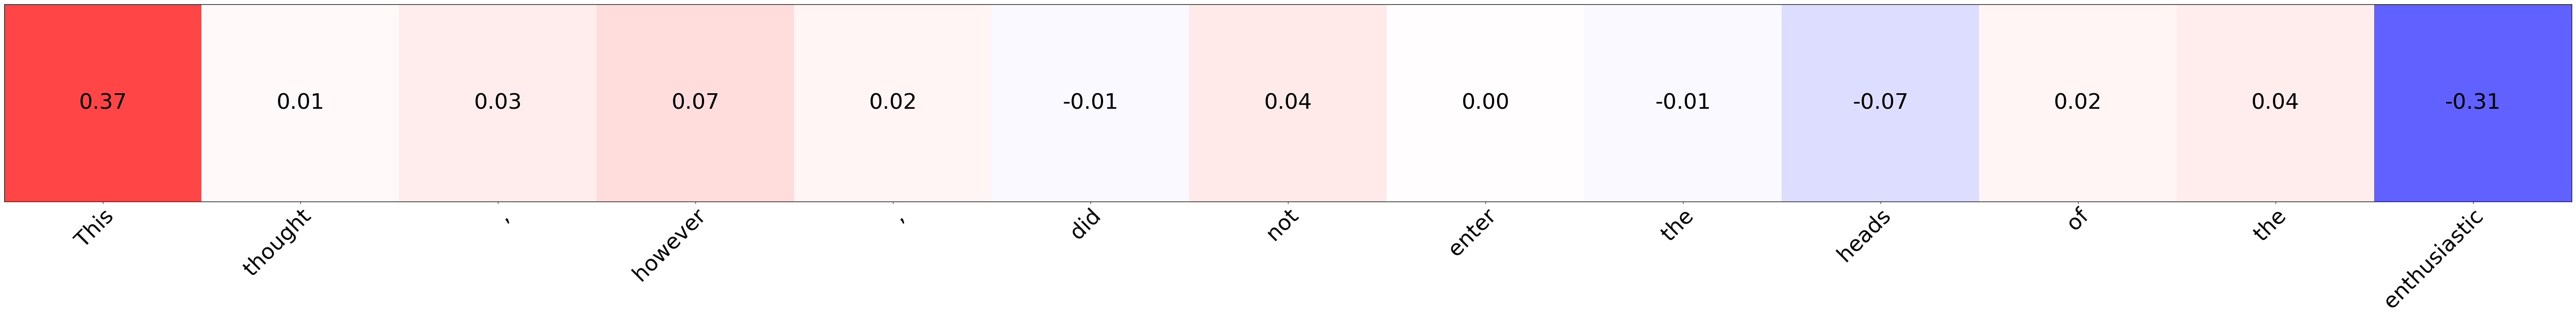

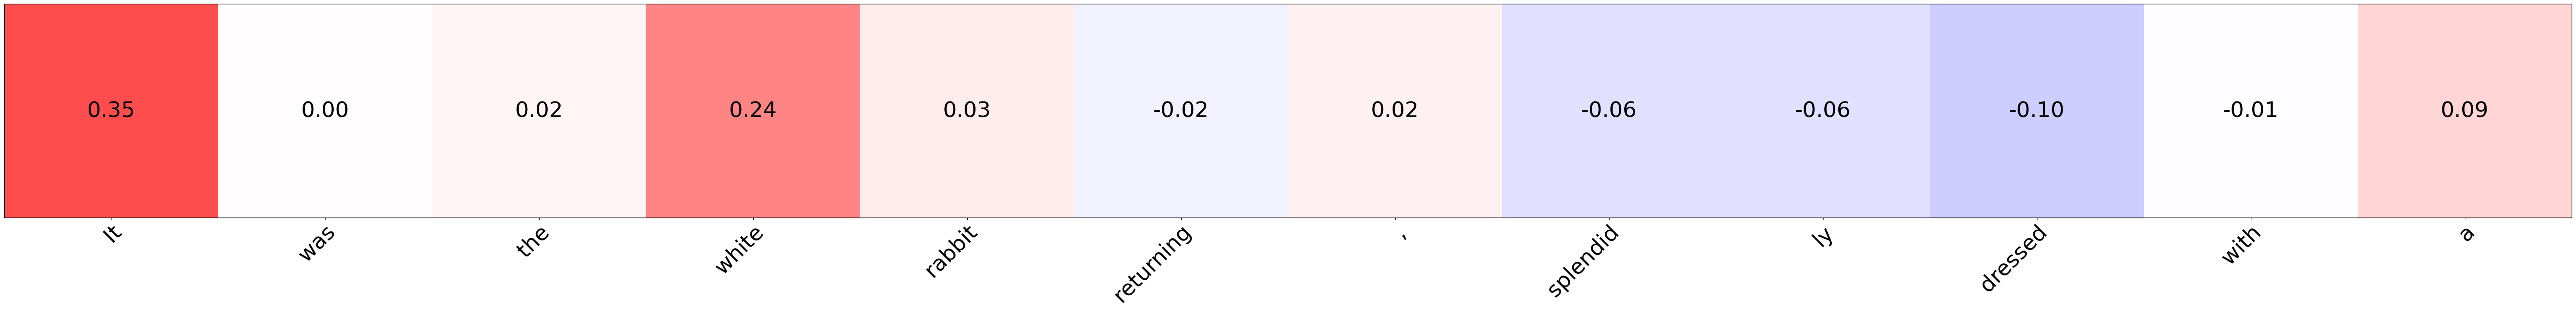

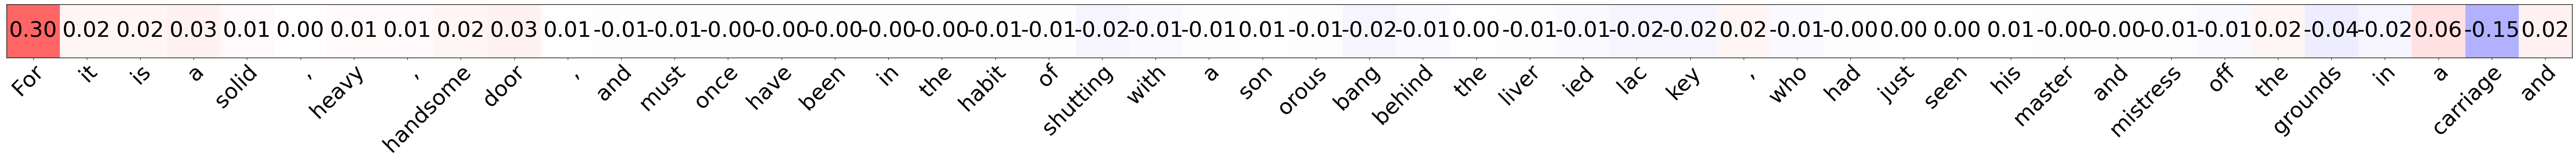

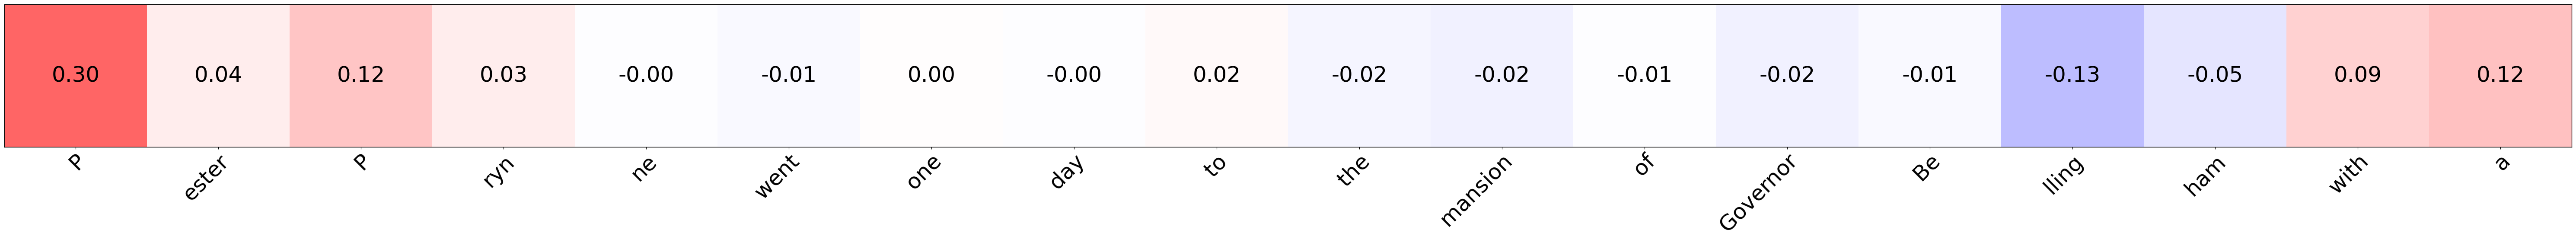

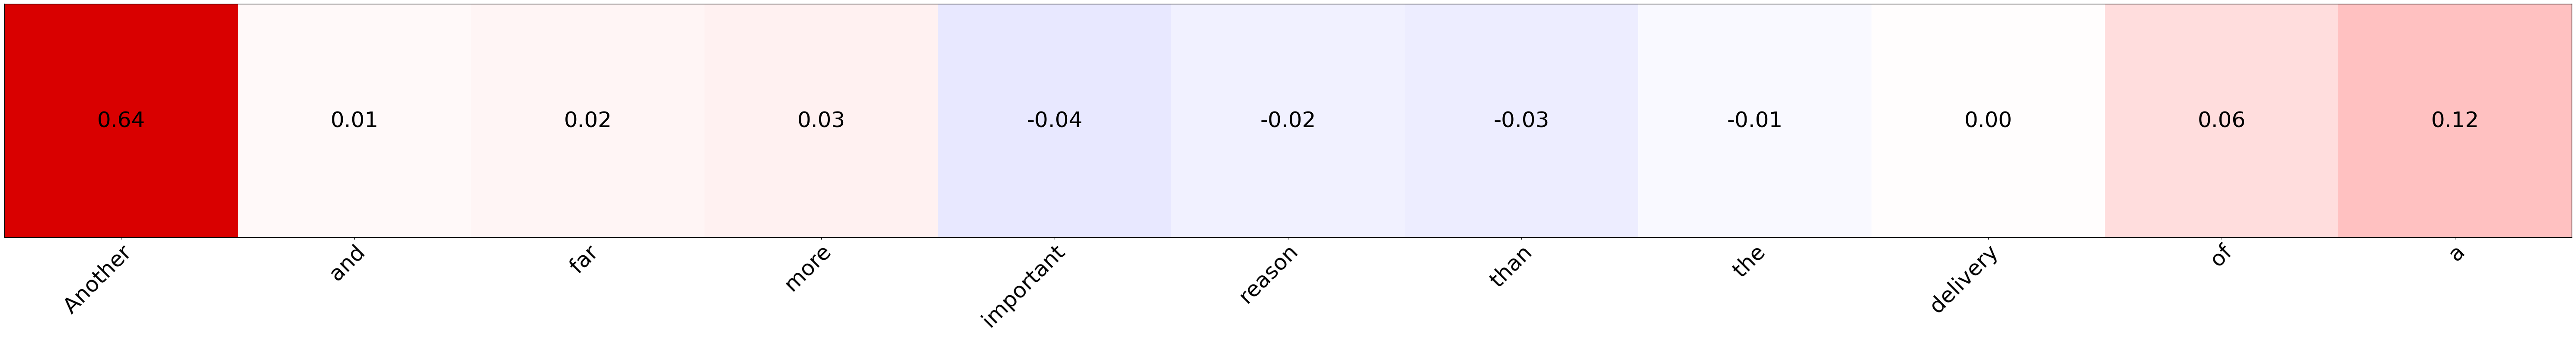

In [38]:
for i, result in enumerate(results):
    plot_contrastive_token_saliency(result["logit_trans_vect_dict"],result["layer_attributions"],result["logits_modules"],result["decoder_input_ids"],token)

## head x time heatmap

In [57]:
def plot_head_frame_contrib(logits_modules):
    head_frame_contrib = logit_modules["l_lin_enc_x_i_heads"].norm(dim=-1)  # [heads, src_len]

    df = pd.DataFrame(
        head_frame_contrib.cpu().numpy(),
        columns=[f"frame_{i}" for i in range(src_len)],
        index=[f"head_{h}" for h in range(num_heads)]
    )

    sns.heatmap(df, cmap="Blues")
    plt.title("Head-wise cross-attention contribution")
    plt.xlabel("Encoder frame")
    plt.ylabel("Head")
    plt.show()


## cross-attention vs. self-attention dominace

In [53]:
def plot_attentions(logit_trans_vect_dict,logits_modules):
    cross = torch.stack(logits_modules["enc_lin_logits_layers"])  # [layers, src_len, vocab]
    self_attn = logit_trans_vect_dict["lin_x_j"]     # [layers, tgt_len, vocab]

    cross_norm = cross.norm(dim=(-2, -1))
    self_norm = self_attn.norm(dim=(-2, -1))

    # normalize per layer
    cross_norm /= cross_norm.max()
    self_norm /= self_norm.max()

    if self_norm.ndim > 1:
        self_norm = self_norm.mean(dim=-1)

    plt.plot(cross_norm.cpu(), label="Cross-attention")
    plt.plot(self_norm.cpu(), label="Self-attention")
    plt.legend()
    plt.title("Audio vs language contribution by layer")
    plt.xlabel("Layer")
    plt.ylabel("Logit contribution magnitude")
    plt.show()


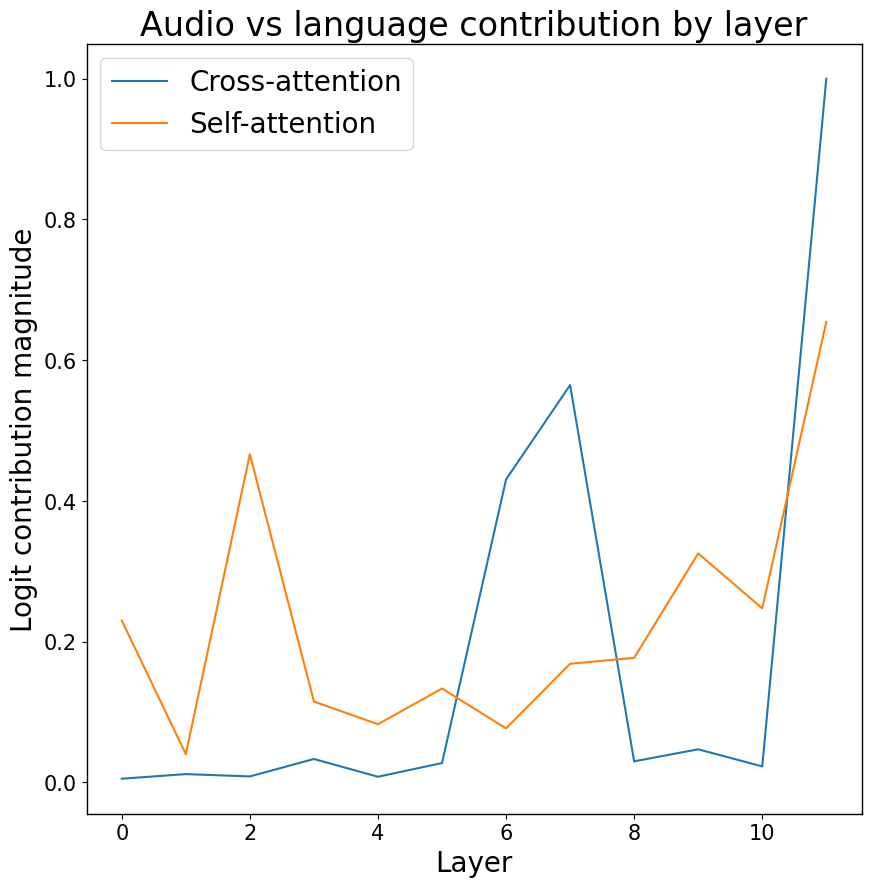

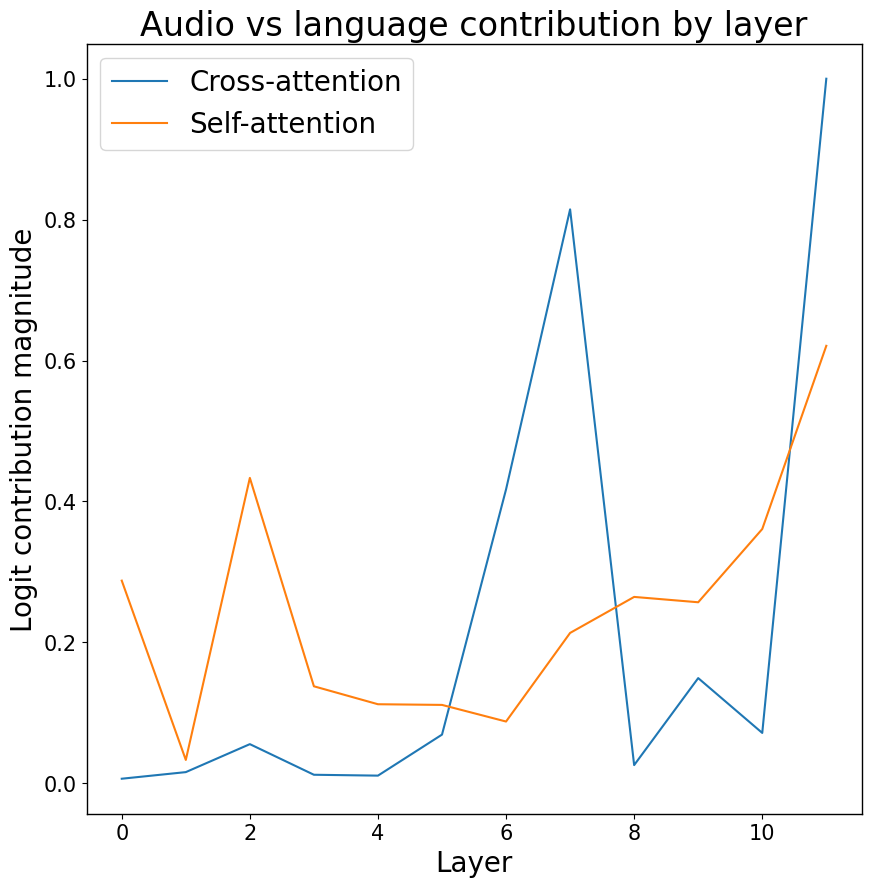

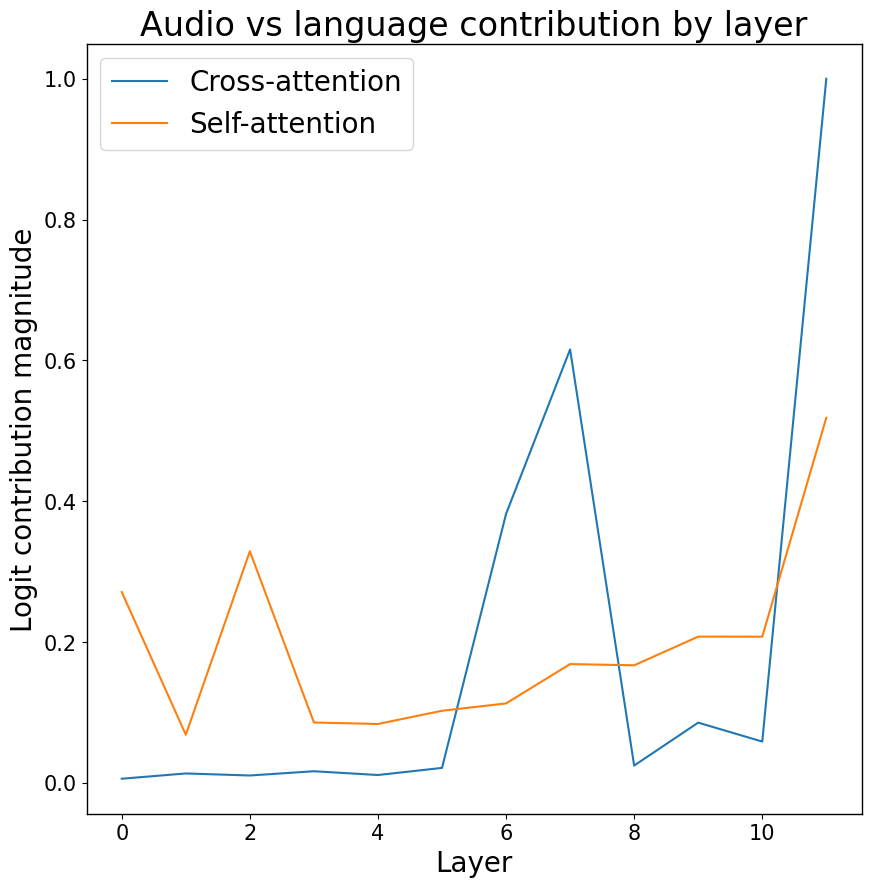

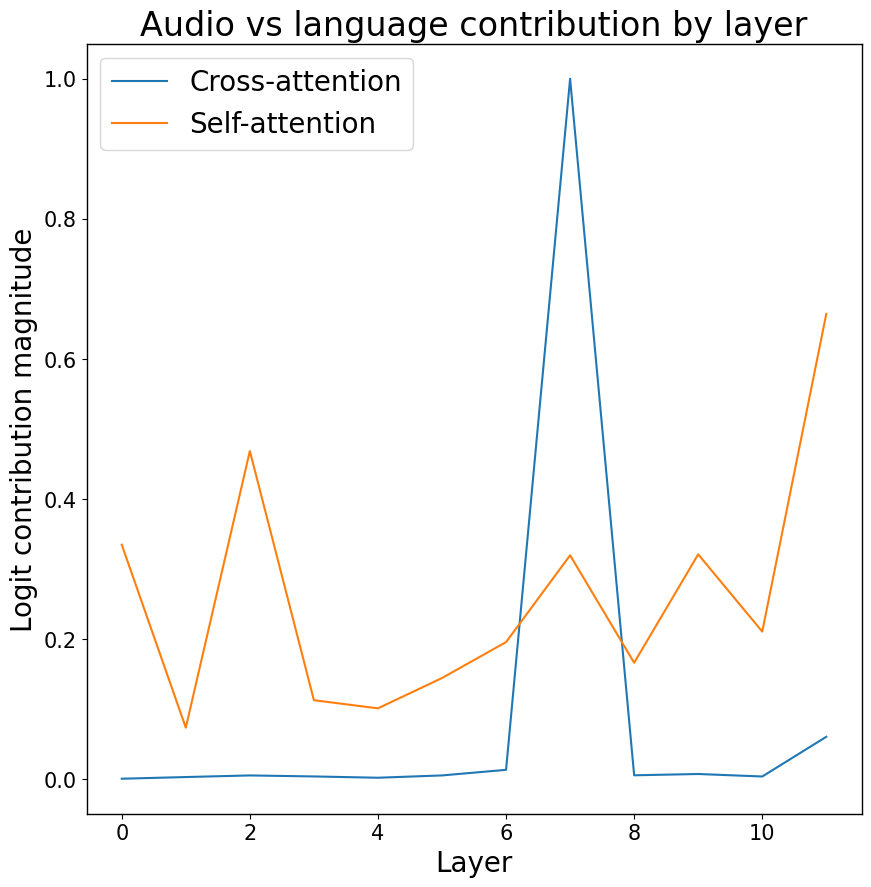

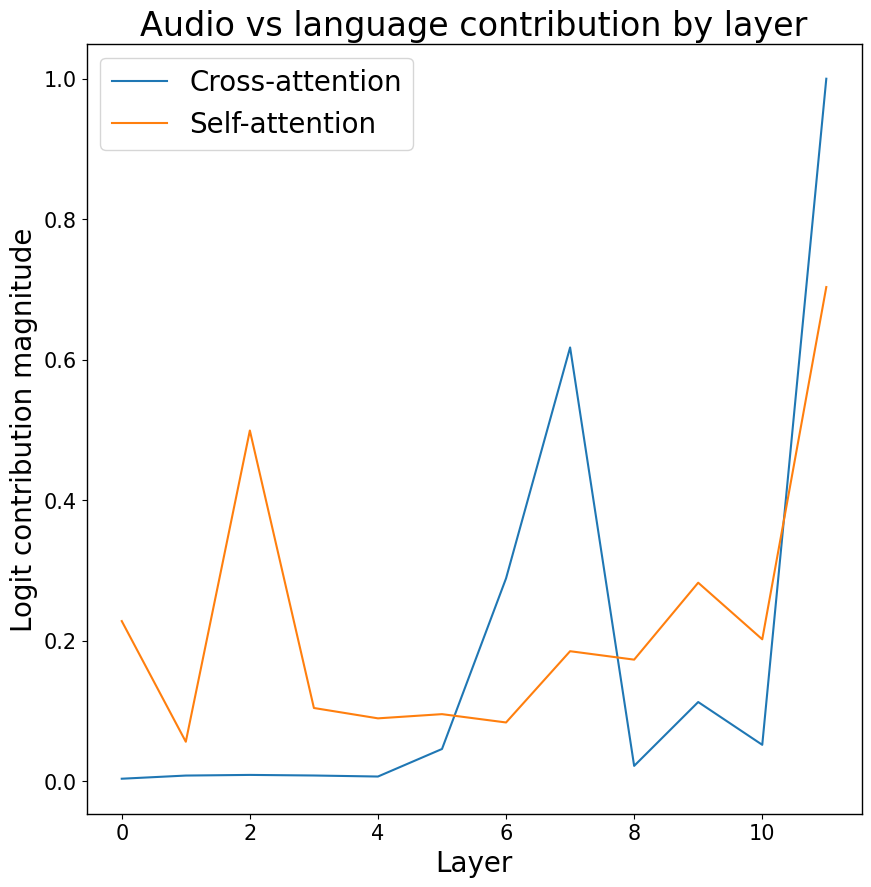

In [54]:
for i, result in enumerate(results):
    plot_attentions(result["logit_trans_vect_dict"],result["logits_modules"])